# Week 12 - Machine Learning Practice
**Data Science Workflow — Part 2**

Train two ML models on each of the two datasets, evaluate their performance, and suggest improvements.

---
## Install & Import Libraries

In [1]:
# Install required libraries if not already installed
# !pip install pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---
# PART 1 — Titanic Dataset (Classification)
**Problem:** Predict whether a passenger survived (1) or not (0).

**Models:** Logistic Regression & Decision Tree Classifier

## Step 1 — Load & Clean the Data

In [3]:
# Load dataset
titanic = pd.read_csv('titanic.csv')
print("Shape:", titanic.shape)
titanic.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check missing values
print("Missing values:\n", titanic.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# --- Cleaning ---

# Fill missing Age with median
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

# Fill missing Embarked with mode
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values), Name, Ticket, PassengerId
titanic.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
titanic['Sex'] = le.fit_transform(titanic['Sex'])          # male=1, female=0
titanic['Embarked'] = le.fit_transform(titanic['Embarked'])  # C=0, Q=1, S=2

print("Cleaned shape:", titanic.shape)
print("Missing values after cleaning:\n", titanic.isnull().sum())
titanic.head()

Cleaned shape: (891, 8)
Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## Step 2 — Split into Features & Target

In [6]:
# Features (X) and Target (y)
X_titanic = titanic.drop(columns=['Survived'])
y_titanic = titanic['Survived']

# Train / Test split (80% train, 20% test)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

print("Training samples:", X_train_t.shape[0])
print("Testing  samples:", X_test_t.shape[0])

Training samples: 712
Testing  samples: 179


## Step 3 — Train Model 1: Logistic Regression

In [7]:
# Train
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_t, y_train_t)

# Predict
lr_pred = lr_model.predict(X_test_t)

# Evaluate
lr_acc  = accuracy_score(y_test_t, lr_pred)
lr_prec = precision_score(y_test_t, lr_pred)
lr_rec  = recall_score(y_test_t, lr_pred)

print("=== Logistic Regression ===")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall   : {lr_rec:.4f}")

=== Logistic Regression ===
Accuracy : 0.8101
Precision: 0.7857
Recall   : 0.7432


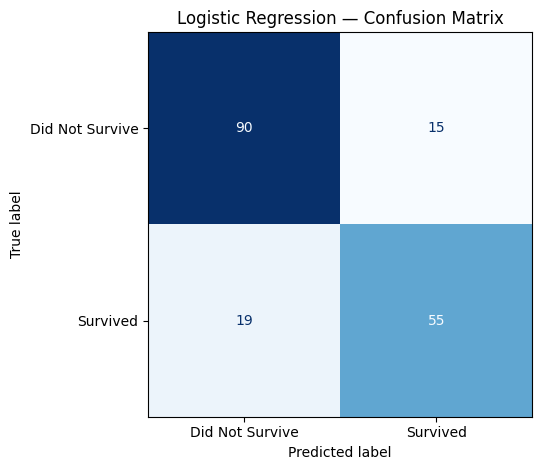

In [8]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test_t, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Did Not Survive', 'Survived'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 4 — Train Model 2: Decision Tree Classifier

In [9]:
# Train
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_t, y_train_t)

# Predict
dt_pred = dt_model.predict(X_test_t)

# Evaluate
dt_acc  = accuracy_score(y_test_t, dt_pred)
dt_prec = precision_score(y_test_t, dt_pred)
dt_rec  = recall_score(y_test_t, dt_pred)

print("=== Decision Tree Classifier ===")
print(f"Accuracy : {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall   : {dt_rec:.4f}")

=== Decision Tree Classifier ===
Accuracy : 0.7989
Precision: 0.8276
Recall   : 0.6486


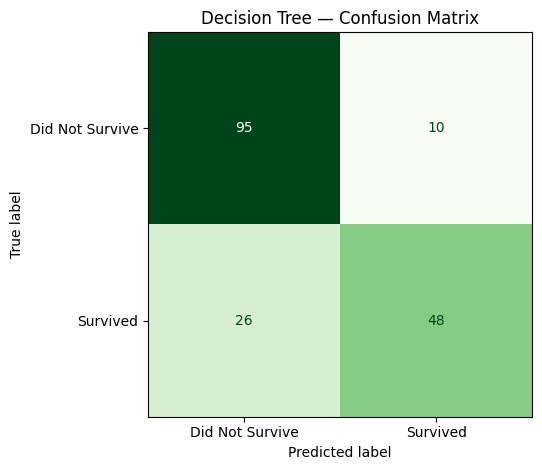

In [10]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test_t, dt_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Did Not Survive', 'Survived'])
disp2.plot(colorbar=False, cmap='Greens')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 5 — Compare Titanic Models

=== Titanic — Model Comparison ===
              Model  Accuracy  Precision   Recall
Logistic Regression  0.810056   0.785714 0.743243
      Decision Tree  0.798883   0.827586 0.648649


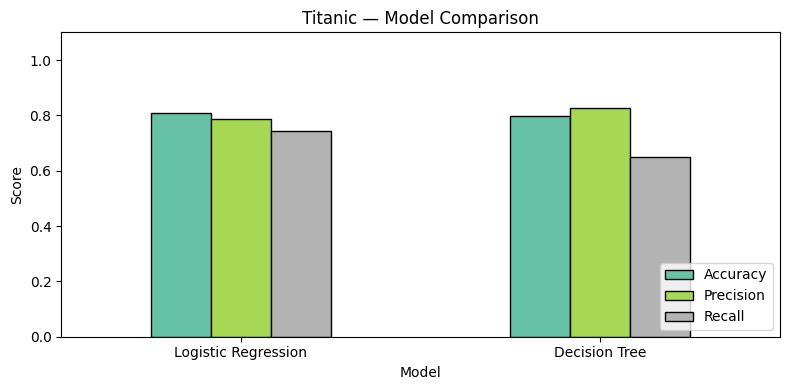

In [11]:
titanic_results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Decision Tree'],
    'Accuracy' : [lr_acc, dt_acc],
    'Precision': [lr_prec, dt_prec],
    'Recall'   : [lr_rec, dt_rec]
})

print("=== Titanic — Model Comparison ===")
print(titanic_results.to_string(index=False))

# Bar chart
titanic_results.set_index('Model')[['Accuracy', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(8, 4), colormap='Set2', edgecolor='black'
)
plt.title('Titanic — Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 6 — Suggestions to Improve Titanic Metrics

| Suggestion | Why it helps |
|---|---|
| **Feature Engineering** — create `FamilySize = SibSp + Parch + 1` | Captures family travel patterns linked to survival |
| **Extract title from Name** (Mr, Mrs, Miss, Master) | Title reflects social status and age group |
| **Try Random Forest or XGBoost** | Ensemble methods reduce variance and usually outperform single trees |
| **Cross-validation (k-fold)** | More reliable metric estimate than a single train/test split |
| **Hyperparameter tuning (GridSearchCV)** | Finds the best `max_depth`, `C`, etc. automatically |
| **Handle class imbalance** — use `class_weight='balanced'` | More survivors than non-survivors → models can be biased |
| **Scale features** with `StandardScaler` | Logistic Regression is sensitive to feature scale |

---
# PART 2 — New York Airbnb Dataset (Regression)
**Problem:** Predict the nightly `price` of an Airbnb listing.

**Models:** Linear Regression & Decision Tree Regressor

## Step 1 — Load & Clean the Data

In [12]:
# Load dataset
airbnb = pd.read_csv('AB_NYC_2019.csv')
print("Shape:", airbnb.shape)
airbnb.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [13]:
# Check missing values
print("Missing values:\n", airbnb.isnull().sum())

Missing values:
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [14]:
# --- Cleaning ---

# Drop columns not useful for prediction
airbnb.drop(columns=['id', 'name', 'host_name', 'last_review'], inplace=True)

# Fill missing reviews_per_month with 0 (no reviews = 0 per month)
airbnb['reviews_per_month'].fillna(0, inplace=True)

# Remove listings with price = 0 (invalid)
airbnb = airbnb[airbnb['price'] > 0]

# Remove extreme outliers in price (above 99th percentile)
p99 = airbnb['price'].quantile(0.99)
airbnb = airbnb[airbnb['price'] <= p99]

# Encode categorical columns
le2 = LabelEncoder()
airbnb['neighbourhood_group'] = le2.fit_transform(airbnb['neighbourhood_group'])
airbnb['neighbourhood']       = le2.fit_transform(airbnb['neighbourhood'])
airbnb['room_type']           = le2.fit_transform(airbnb['room_type'])

print("Cleaned shape:", airbnb.shape)
print("Missing values after cleaning:\n", airbnb.isnull().sum())
airbnb.head()

Cleaned shape: (48410, 12)
Missing values after cleaning:
 host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,1,107,40.64749,-73.97237,1,149,1,9,0.21,6,365
1,2845,2,126,40.75362,-73.98377,0,225,1,45,0.38,2,355
2,4632,2,93,40.80902,-73.94190,1,150,3,0,0.00,1,365
3,4869,1,41,40.68514,-73.95976,0,89,1,270,4.64,1,194
4,7192,2,61,40.79851,-73.94399,0,80,10,9,0.10,1,0


## Step 2 — Split into Features & Target

In [15]:
# Features (X) and Target (y)
X_airbnb = airbnb.drop(columns=['price'])
y_airbnb = airbnb['price']

# Train / Test split (80% train, 20% test)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_airbnb, y_airbnb, test_size=0.2, random_state=42
)

print("Training samples:", X_train_a.shape[0])
print("Testing  samples:", X_test_a.shape[0])

Training samples: 38728
Testing  samples: 9682


## Step 3 — Train Model 1: Linear Regression

In [16]:
# Train
linreg = LinearRegression()
linreg.fit(X_train_a, y_train_a)

# Predict
linreg_pred = linreg.predict(X_test_a)

# Evaluate
linreg_r2   = r2_score(y_test_a, linreg_pred)
linreg_mae  = mean_absolute_error(y_test_a, linreg_pred)
linreg_rmse = np.sqrt(mean_squared_error(y_test_a, linreg_pred))

print("=== Linear Regression ===")
print(f"R²  : {linreg_r2:.4f}")
print(f"MAE : {linreg_mae:.2f}")
print(f"RMSE: {linreg_rmse:.2f}")

=== Linear Regression ===
R²  : 0.3423
MAE : 54.08
RMSE: 84.60


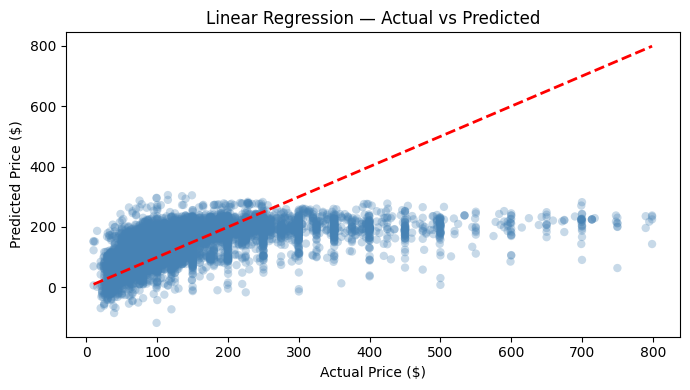

In [17]:
# Actual vs Predicted — Linear Regression
plt.figure(figsize=(7, 4))
plt.scatter(y_test_a, linreg_pred, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test_a.min(), y_test_a.max()], [y_test_a.min(), y_test_a.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

## Step 4 — Train Model 2: Decision Tree Regressor

In [18]:
# Train
dtr_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dtr_model.fit(X_train_a, y_train_a)

# Predict
dtr_pred = dtr_model.predict(X_test_a)

# Evaluate
dtr_r2   = r2_score(y_test_a, dtr_pred)
dtr_mae  = mean_absolute_error(y_test_a, dtr_pred)
dtr_rmse = np.sqrt(mean_squared_error(y_test_a, dtr_pred))

print("=== Decision Tree Regressor ===")
print(f"R²  : {dtr_r2:.4f}")
print(f"MAE : {dtr_mae:.2f}")
print(f"RMSE: {dtr_rmse:.2f}")

=== Decision Tree Regressor ===
R²  : 0.4346
MAE : 48.57
RMSE: 78.44


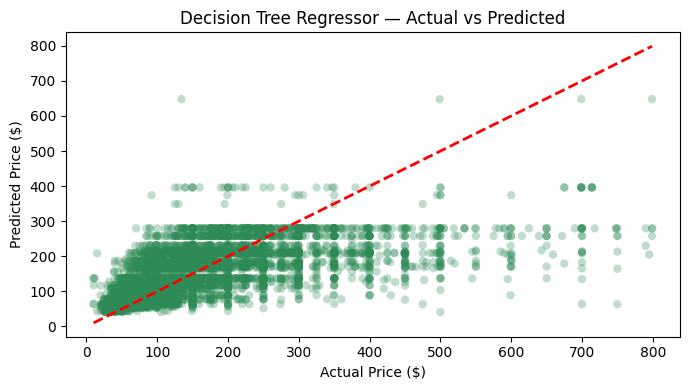

In [19]:
# Actual vs Predicted — Decision Tree Regressor
plt.figure(figsize=(7, 4))
plt.scatter(y_test_a, dtr_pred, alpha=0.3, color='seagreen', edgecolors='none')
plt.plot([y_test_a.min(), y_test_a.max()], [y_test_a.min(), y_test_a.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Decision Tree Regressor — Actual vs Predicted')
plt.tight_layout()
plt.show()

## Step 5 — Compare Airbnb Models

=== Airbnb — Model Comparison ===
                  Model       R²       MAE      RMSE
      Linear Regression 0.342314 54.083497 84.598425
Decision Tree Regressor 0.434554 48.570375 78.441950


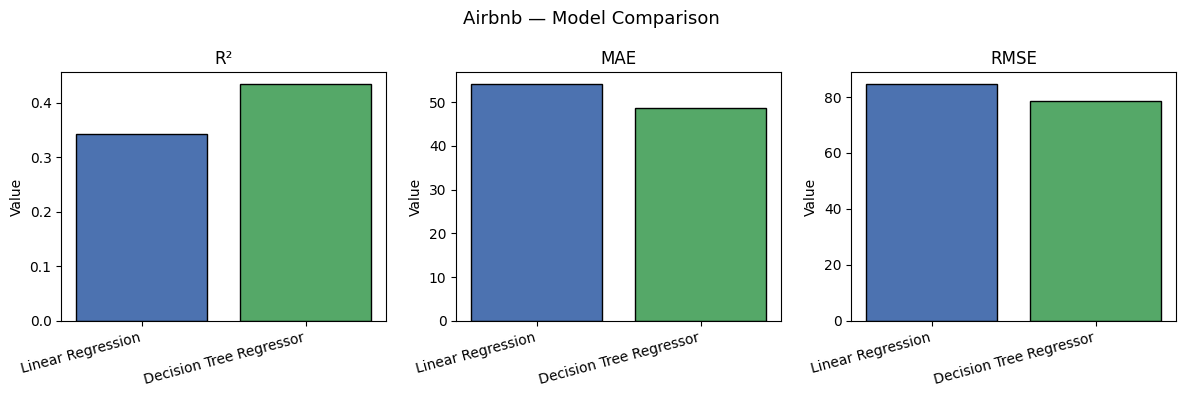

In [20]:
airbnb_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor'],
    'R²'   : [linreg_r2, dtr_r2],
    'MAE'  : [linreg_mae, dtr_mae],
    'RMSE' : [linreg_rmse, dtr_rmse]
})

print("=== Airbnb — Model Comparison ===")
print(airbnb_results.to_string(index=False))

# Bar chart for R²
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ['R²', 'MAE', 'RMSE']
colors  = ['#4C72B0', '#55A868']

for ax, metric in zip(axes, metrics):
    ax.bar(airbnb_results['Model'], airbnb_results[metric], color=colors, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.set_xticklabels(airbnb_results['Model'], rotation=15, ha='right')

plt.suptitle('Airbnb — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — Suggestions to Improve Airbnb Metrics

| Suggestion | Why it helps |
|---|---|
| **Log-transform price** (`np.log1p`) | Price is right-skewed; log scale helps linear models fit better |
| **Feature Engineering** — distance to city centre from lat/lon | Location is a major price driver |
| **Try Random Forest Regressor** | Handles non-linear relationships much better than Linear Regression |
| **Try Gradient Boosting (XGBoost / LightGBM)** | State-of-the-art for tabular regression tasks |
| **Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)** | Finds optimal `max_depth`, `n_estimators`, etc. |
| **Better outlier handling** — use IQR or log-cap | Extreme prices distort the model's learning |
| **Cross-validation (k-fold)** | Single split can give misleading R² on large datasets |

---
# Summary

| Dataset | Model | Key Metric | Score |
|---|---|---|---|
| Titanic | Logistic Regression | Accuracy | See output above |
| Titanic | Decision Tree | Accuracy | See output above |
| Airbnb | Linear Regression | R² | See output above |
| Airbnb | Decision Tree Regressor | R² | See output above |

**Key Takeaways:**
- For **classification** (Titanic), we used Accuracy, Precision, Recall, and Confusion Matrix.
- For **regression** (Airbnb), we used R², MAE, and RMSE.
- Both datasets can benefit from ensemble methods (Random Forest, XGBoost) and proper feature engineering to improve performance.